# 📌 Employee Attrition Prediction using Machine Learning
#
# 🎯 Problem Description
# Employee attrition is a major issue for organizations, as losing employees increases recruitment costs and reduces productivity.
# The goal of this project is to predict whether an employee will leave the company or stay, based on various personal and
# job-related factors.
#
# 🔍 Problem Type
# **Binary Classification**
# - `1` → Attrition (Employee leaves)
# - `0` → No Attrition (Employee stays)
#
# 📁 Dataset
# **Source**: Kaggle (IBM HR Analytics Attrition Dataset)  
# Link (for reference): https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset
#
# ✅ Model
# 1) Logistic Regression (baseline + balanced + tuned)
#
# This notebook includes:
# - Missing value checks
# - EDA (target plots, categorical vs target, numeric distributions, missing heatmap, correlation heatmap)
# - Feature engineering examples
# - Proper preprocessing with Pipeline (OneHot + Scaling) to avoid leakage
# - Stratified split
# - Imbalance handling (class_weight='balanced')
# - GridSearchCV tuning
# - ROC-AUC + ROC Curve
# - Threshold tuning (F1-based with recall constraint)
# - Cross-validation (mean ± std)
# - Baseline vs balanced vs tuned comparison


# 1) Import Libraries

In [1]:
# ## 1) Import Libraries

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    precision_score, recall_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Libraries imported!")

✅ Libraries imported!


# 2) Load Dataset (Google Drive / Local)

In [2]:
# ## 2) Load Dataset (Google Drive / Local)
# If you're using Colab + Drive, keep this. Otherwise, load from local path.

# %%
# --- Google Colab Drive (optional) ---
from google.colab import drive
drive.mount("/content/drive")

file_path = "/content/drive/MyDrive/WA_Fn-UseC_-HR-Employee-Attrition.csv"  # change if needed
df = pd.read_csv(file_path)

print("✅ Dataset loaded!")
print("Shape:", df.shape)
display(df.head())


Mounted at /content/drive
✅ Dataset loaded!
Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# 3) Basic Dataset Checks

In [3]:
# ## 3) Basic Dataset Checks

# %%
print("Info:")
display(df.info())

print("\nMissing values per column:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

print("\nTarget counts:")
display(df["Attrition"].value_counts())


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel          

None


Missing values per column:


,0



Target counts:


,count
Attrition,
No,1233
Yes,237


# 4) Exploratory Data Analysis (EDA)

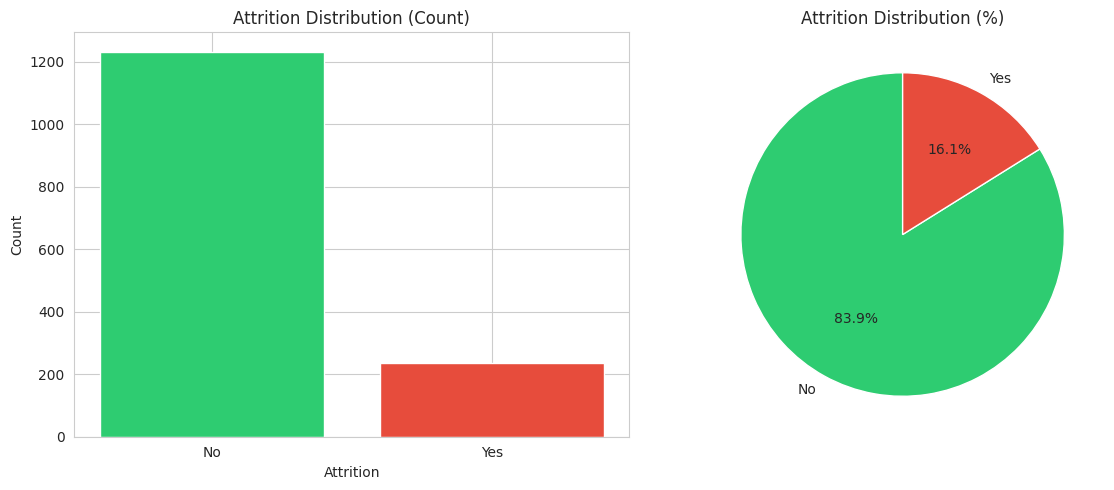

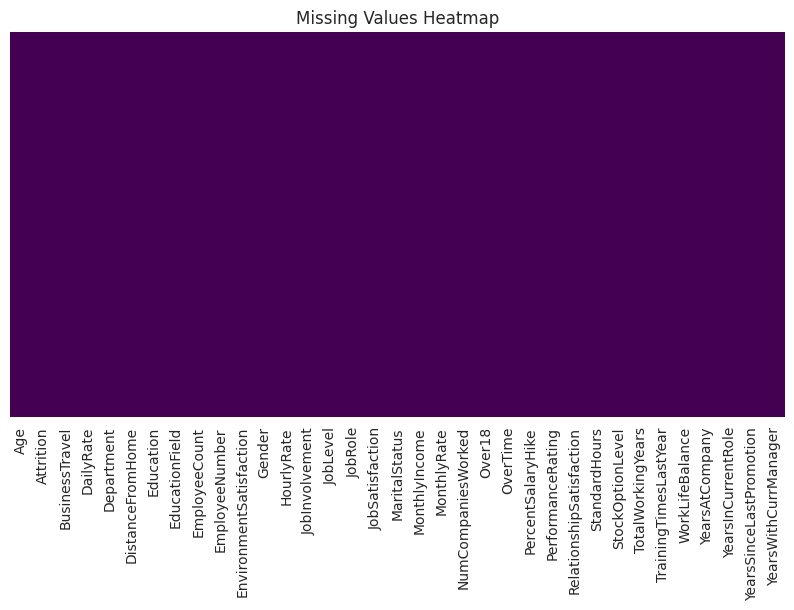

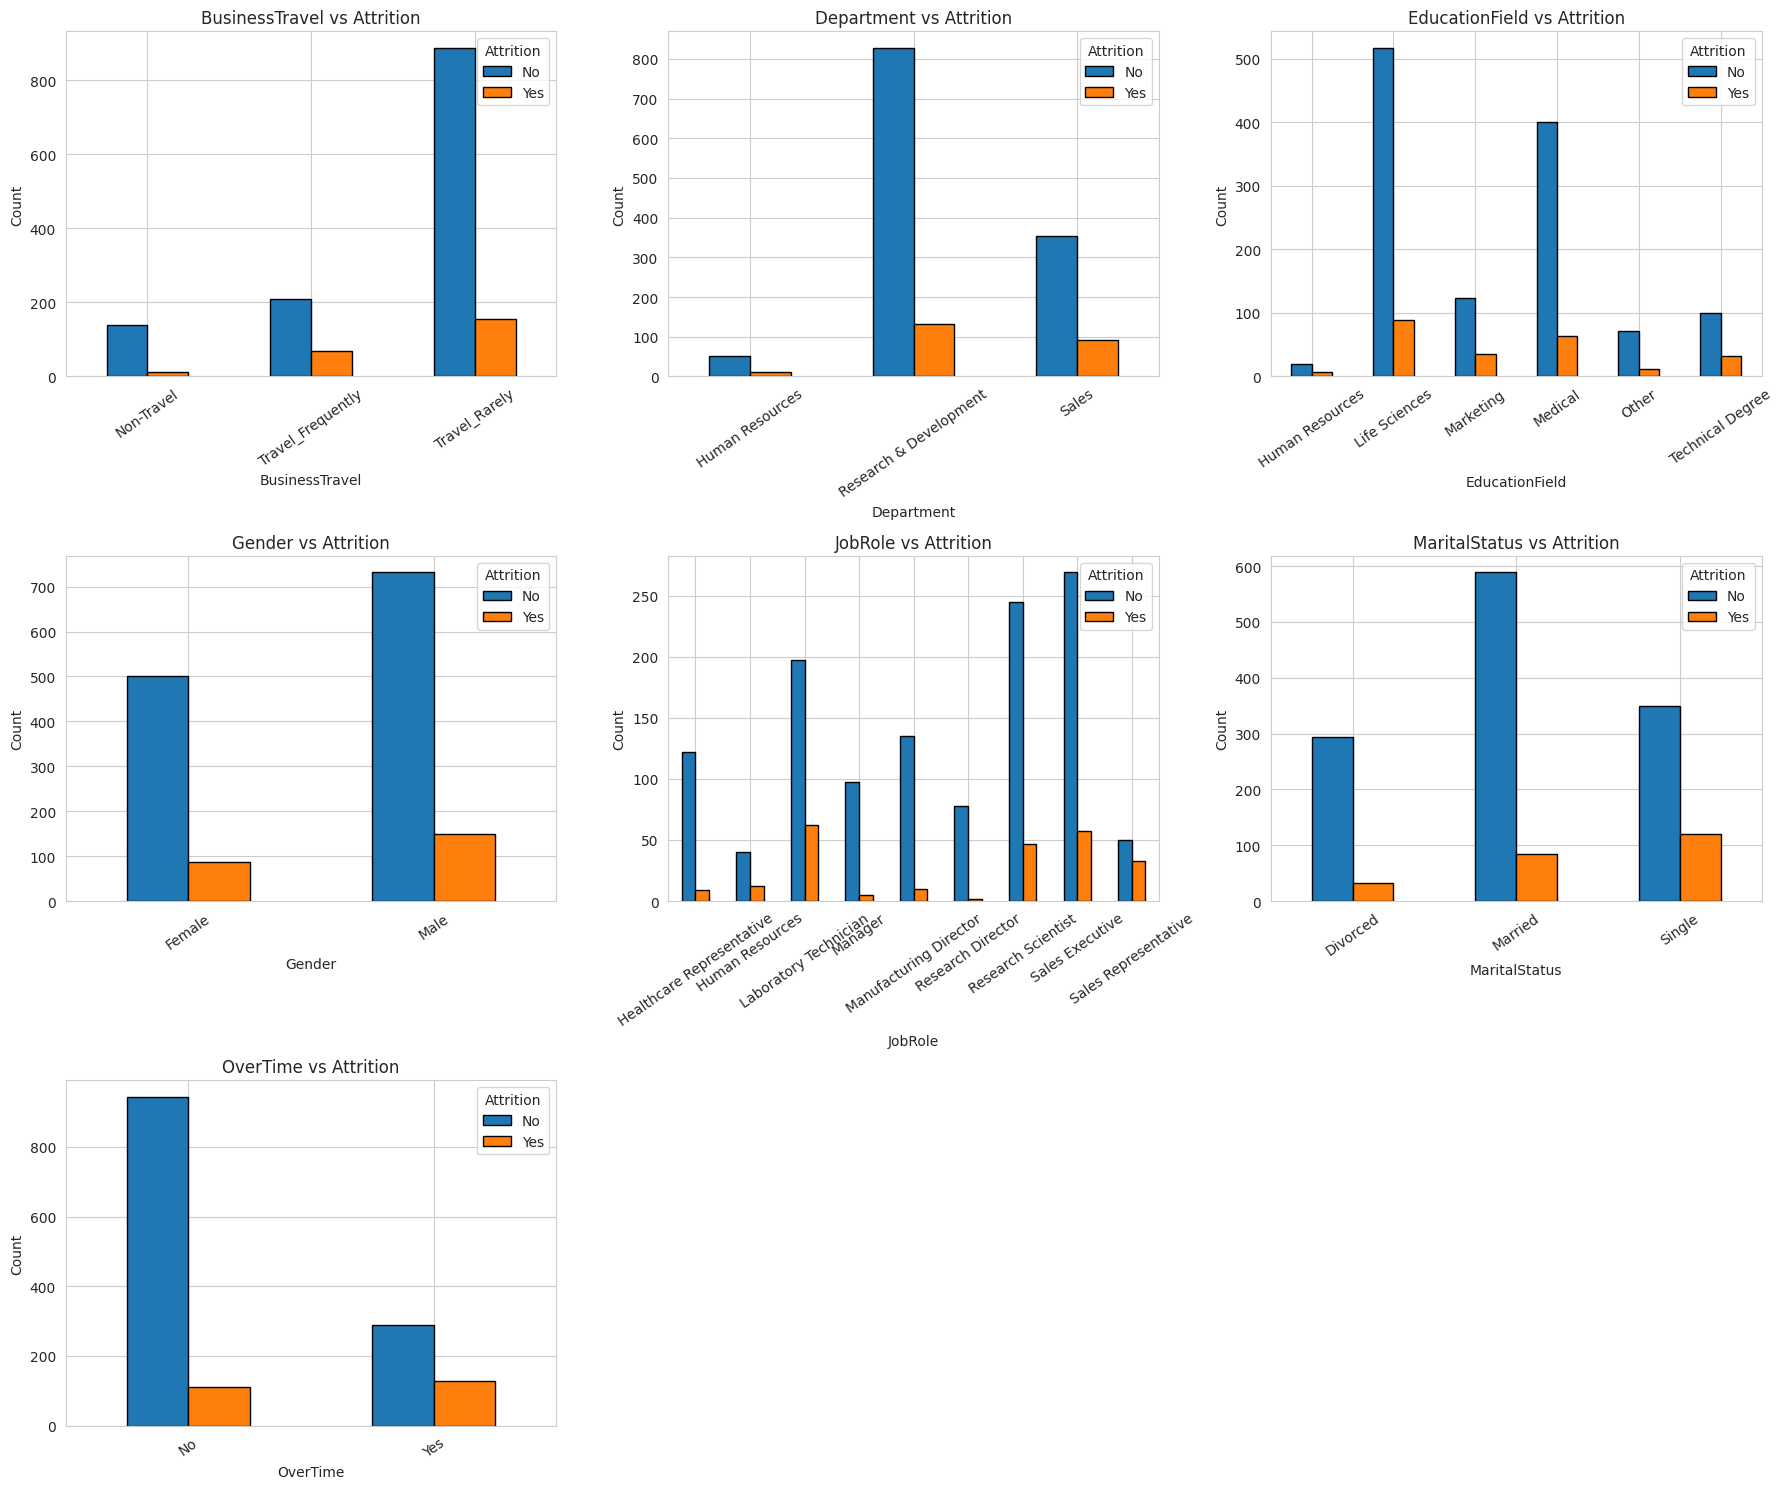

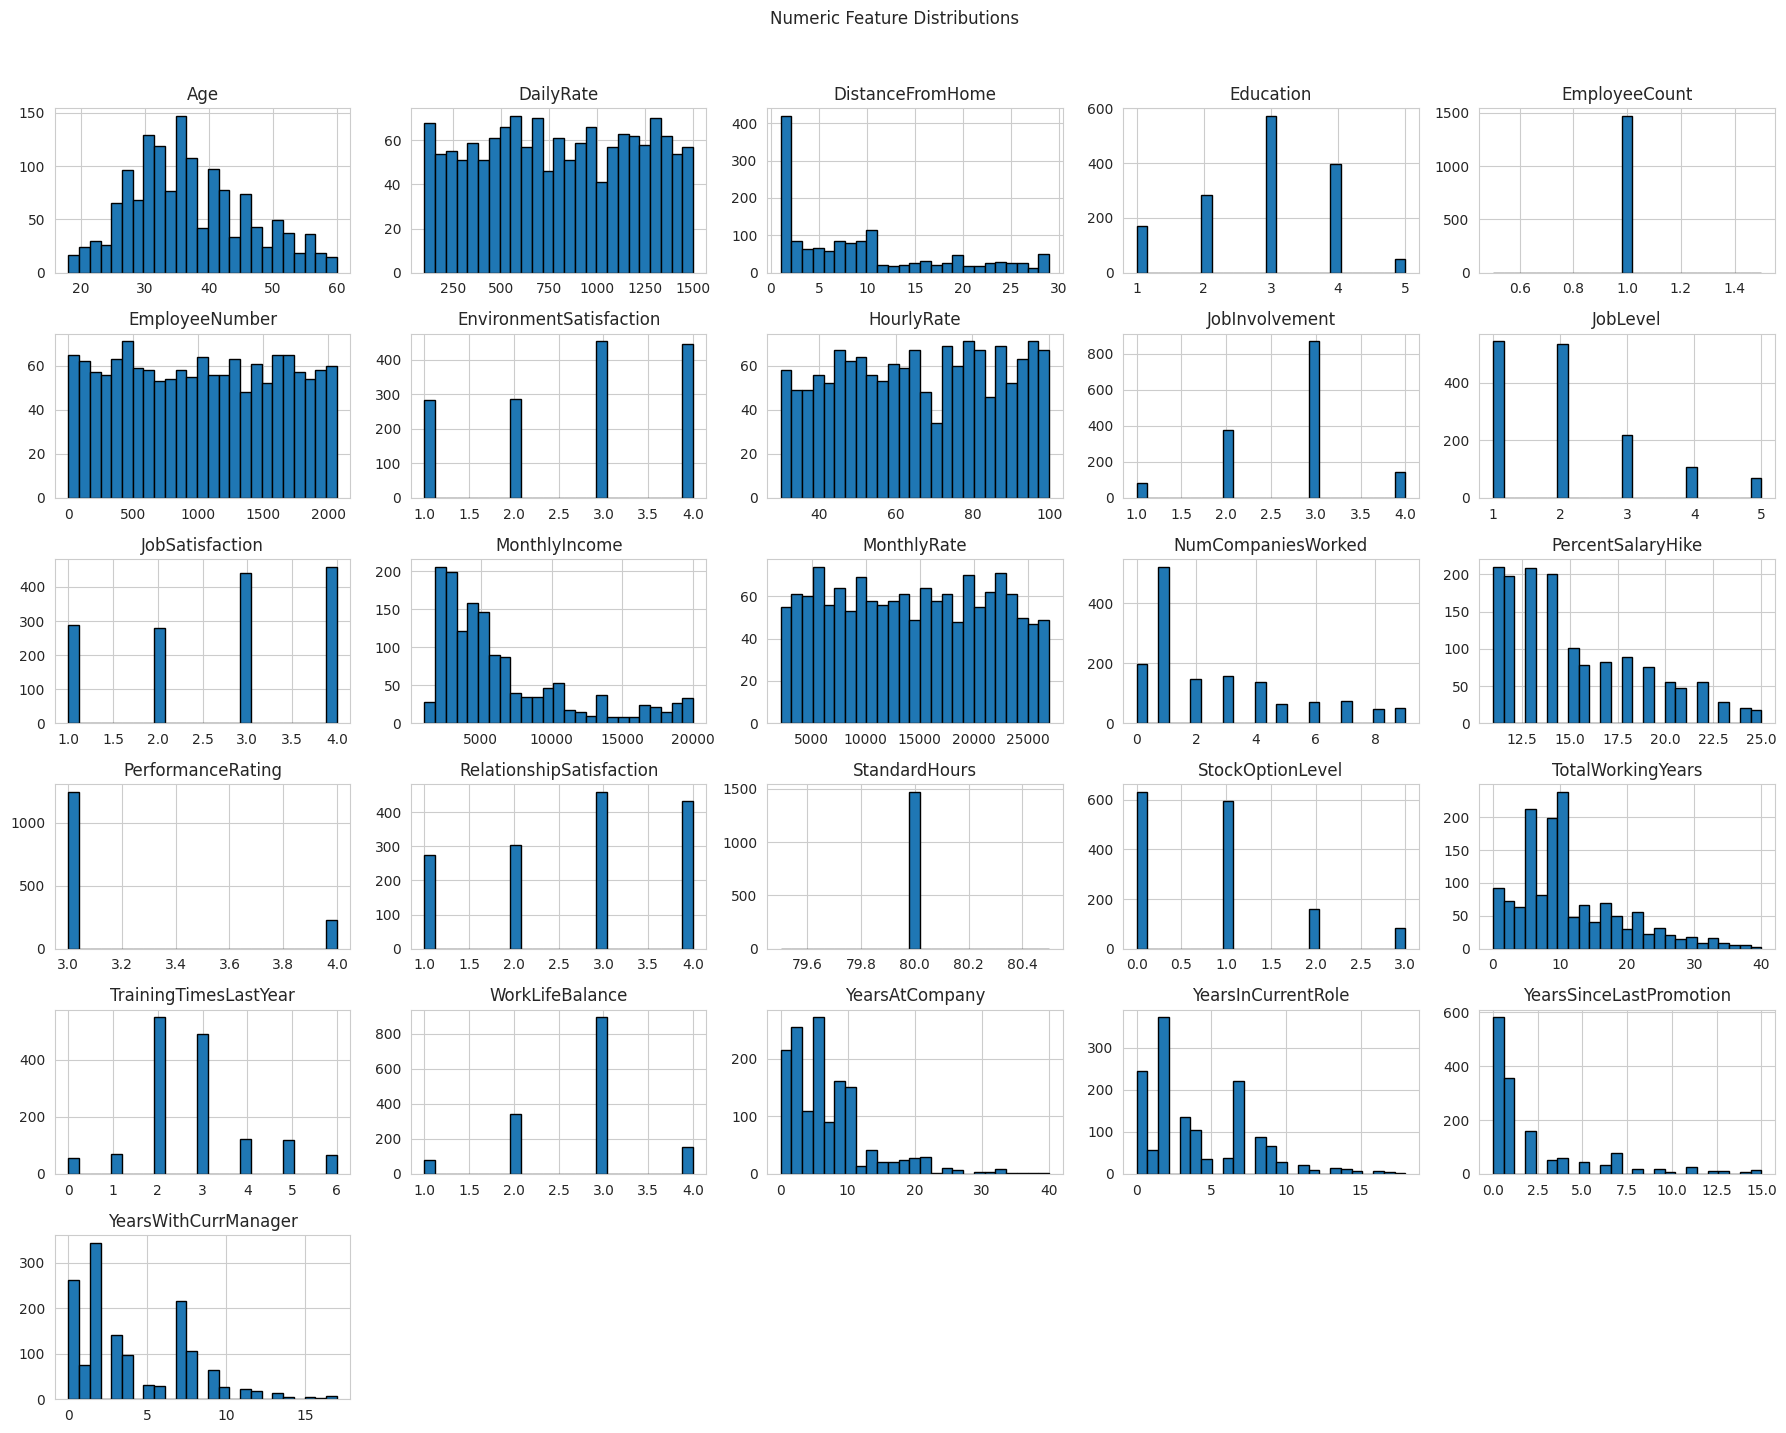

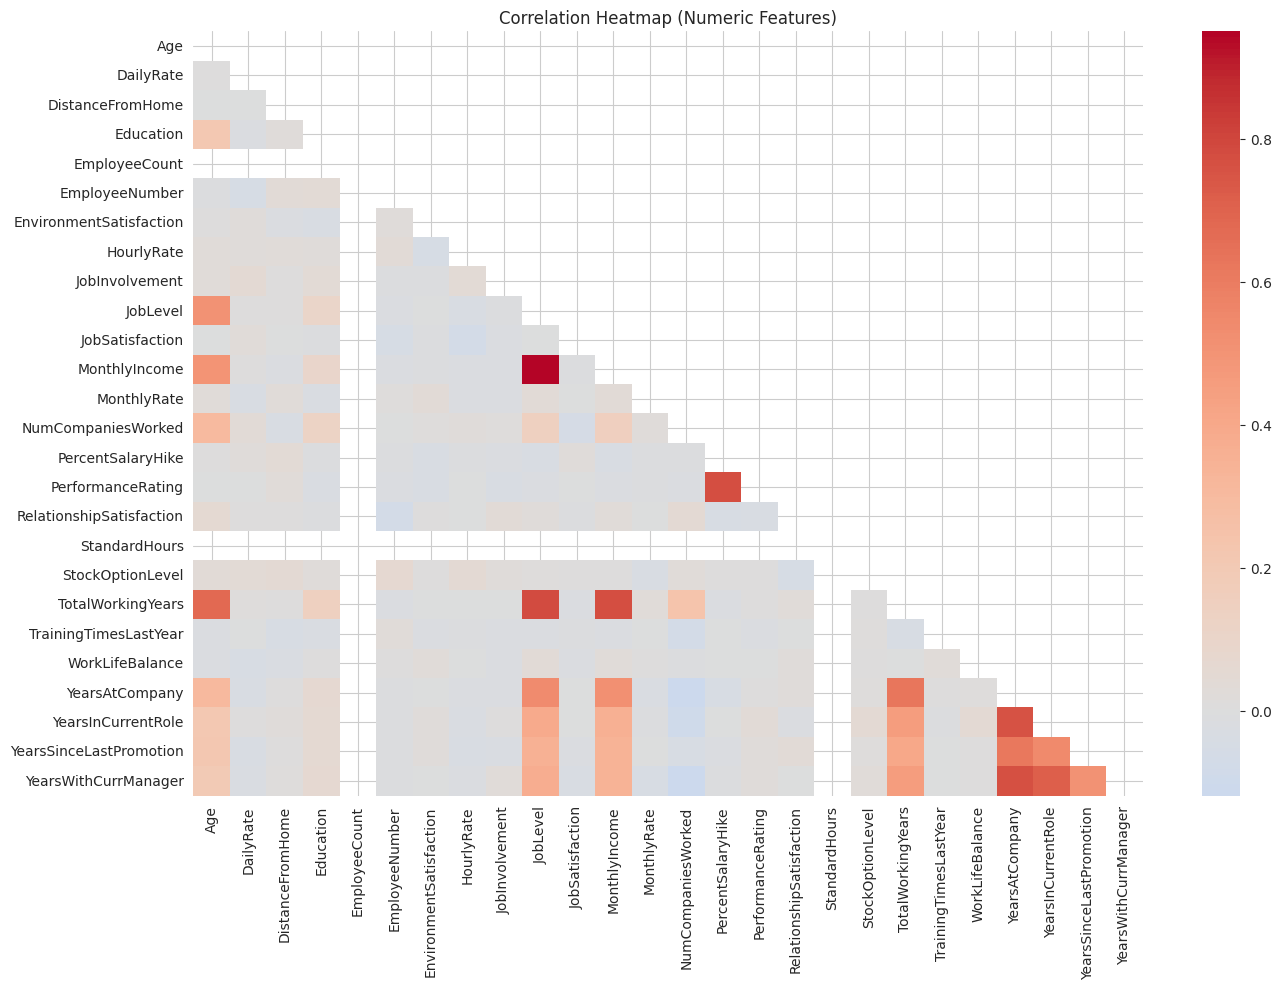

In [4]:
# ## 4) Exploratory Data Analysis (EDA)

# %%
# --- Target distribution (bar + pie) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

attr_counts = df["Attrition"].value_counts()
axes[0].bar(attr_counts.index, attr_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Attrition Distribution (Count)")
axes[0].set_xlabel("Attrition")
axes[0].set_ylabel("Count")

axes[1].pie(attr_counts, labels=attr_counts.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Attrition Distribution (%)")

plt.tight_layout()
plt.show()

# %%
# --- Missing values heatmap ---
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# %%
# --- Categorical vs Target ---
cat_features = [
    "BusinessTravel", "Department", "EducationField", "Gender",
    "JobRole", "MaritalStatus", "OverTime"
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df["Attrition"])
    ct.plot(kind="bar", ax=axes[i], edgecolor="black", rot=35)
    axes[i].set_title(f"{col} vs Attrition")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(len(cat_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# %%
# --- Numeric feature distributions (all numeric columns) ---
num_cols_all = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

df[num_cols_all].hist(bins=25, figsize=(18, 14), edgecolor="black")
plt.suptitle("Numeric Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

# %%
# --- Correlation heatmap (numeric only) ---
plt.figure(figsize=(14, 10))
corr = df.select_dtypes(include=["int64", "float64"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


# 5) Data Preprocessing + Feature Engineering

In [5]:
# ## 5) Data Preprocessing + Feature Engineering

# %%
# Target encoding
y = df["Attrition"].map({"Yes": 1, "No": 0})

# Features
X = df.drop(columns=["Attrition"]).copy()

# Drop constant / irrelevant columns (commonly dropped for this dataset)
drop_cols = ["EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]
X.drop(columns=drop_cols, inplace=True, errors="ignore")

# Feature engineering examples (safe divide)
X["YearsSinceLastPromotion_vs_YearsAtCompany"] = X["YearsSinceLastPromotion"] / (X["YearsAtCompany"] + 1)
X["JobSatisfaction_x_WorkLifeBalance"] = X["JobSatisfaction"] * X["WorkLifeBalance"]

# Define columns
cat_nominal = [
    "BusinessTravel", "Department", "EducationField", "Gender",
    "JobRole", "MaritalStatus", "OverTime"
]

ordinal_like = [
    "Education", "EnvironmentSatisfaction", "JobInvolvement", "JobSatisfaction",
    "PerformanceRating", "RelationshipSatisfaction", "WorkLifeBalance"
]

# Numeric columns (exclude categoricals)
numerical = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical = [c for c in numerical if c not in cat_nominal]
# ensure engineered features included
for fe in ["YearsSinceLastPromotion_vs_YearsAtCompany", "JobSatisfaction_x_WorkLifeBalance"]:
    if fe not in numerical:
        numerical.append(fe)

print("✅ Numerical columns:", len(numerical))
print("✅ Categorical nominal columns:", len(cat_nominal))
print("✅ Ordinal-like columns:", len(ordinal_like))

# Preprocessing transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("ord", "passthrough", ordinal_like),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_nominal),
    ],
    remainder="drop"
)

✅ Numerical columns: 25
✅ Categorical nominal columns: 7
✅ Ordinal-like columns: 7


# 6) Train/Test Split (Stratified)

In [6]:
# ## 6) Train/Test Split (Stratified)

# %%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("\nTrain class distribution:")
display(y_train.value_counts(normalize=True))

Train size: (1176, 32)  Test size: (294, 32)

Train class distribution:


,proportion
Attrition,
0,0.838435
1,0.161565


# 7) Baseline Logistic Regression

In [7]:
# ## 7) Baseline Logistic Regression

# %%
baseline_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)
base_auc = roc_auc_score(y_test, y_proba_base)

print(f"Baseline -> Accuracy: {base_acc:.4f}, F1: {base_f1:.4f}, ROC-AUC: {base_auc:.4f}")
print("\nClassification Report (Baseline):\n", classification_report(y_test, y_pred_base))


Baseline -> Accuracy: 0.8639, F1: 0.4595, ROC-AUC: 0.8108

Classification Report (Baseline):
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       247
           1       0.63      0.36      0.46        47

    accuracy                           0.86       294
   macro avg       0.76      0.66      0.69       294
weighted avg       0.85      0.86      0.85       294



# 8) Balanced Logistic Regression (Handle Imbalance)

In [8]:
# ## 8) Balanced Logistic Regression (Handle Imbalance)

# %%
balanced_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=2000, random_state=42, class_weight="balanced"))
])

balanced_model.fit(X_train, y_train)
y_pred_bal = balanced_model.predict(X_test)
y_proba_bal = balanced_model.predict_proba(X_test)[:, 1]

bal_acc = accuracy_score(y_test, y_pred_bal)
bal_f1 = f1_score(y_test, y_pred_bal)
bal_auc = roc_auc_score(y_test, y_proba_bal)

print(f"Balanced -> Accuracy: {bal_acc:.4f}, F1: {bal_f1:.4f}, ROC-AUC: {bal_auc:.4f}")
print("\nClassification Report (Balanced):\n", classification_report(y_test, y_pred_bal))


Balanced -> Accuracy: 0.7619, F1: 0.4776, ROC-AUC: 0.8080

Classification Report (Balanced):
               precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.37      0.68      0.48        47

    accuracy                           0.76       294
   macro avg       0.65      0.73      0.66       294
weighted avg       0.84      0.76      0.79       294



# 9) Hyperparameter Tuning (GridSearchCV) for Logistic Regression

In [9]:
# ## 9) Hyperparameter Tuning (GridSearchCV) for Logistic Regression
# Tuned for ROC-AUC using CV, inside pipeline (no leakage).

# %%
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(max_iter=3000, random_state=42))
])

param_grid = [
    {"clf__C": [0.01, 0.1, 1, 10],
     "clf__penalty": ["l2"],
     "clf__solver": ["lbfgs"],
     "clf__class_weight": [None, "balanced"]},
    {"clf__C": [0.01, 0.1, 1, 10],
     "clf__penalty": ["l2"],
     "clf__solver": ["liblinear"],
     "clf__class_weight": [None, "balanced"]},
    {"clf__C": [0.01, 0.1, 1, 10],
     "clf__penalty": ["l1"],
     "clf__solver": ["liblinear"],
     "clf__class_weight": [None, "balanced"]},
    {"clf__C": [0.01, 0.1, 1, 10],
     "clf__penalty": ["l1"],
     "clf__solver": ["saga"],
     "clf__class_weight": [None, "balanced"]},
]

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="roc_auc",
    cv=cv5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("✅ Best Params:", grid.best_params_)
print("✅ Best CV ROC-AUC:", grid.best_score_)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)
y_proba_best = best_model.predict_proba(X_test)[:, 1]

best_acc = accuracy_score(y_test, y_pred_best)
best_f1 = f1_score(y_test, y_pred_best)
best_auc = roc_auc_score(y_test, y_proba_best)

print(f"Tuned -> Accuracy: {best_acc:.4f}, F1: {best_f1:.4f}, ROC-AUC: {best_auc:.4f}")
print("\nClassification Report (Tuned):\n", classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 32 candidates, totalling 160 fits
✅ Best Params: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
✅ Best CV ROC-AUC: 0.8412967505673891
Tuned -> Accuracy: 0.8673, F1: 0.4658, ROC-AUC: 0.8115

Classification Report (Tuned):
               precision    recall  f1-score   support

           0       0.89      0.96      0.92       247
           1       0.65      0.36      0.47        47

    accuracy                           0.87       294
   macro avg       0.77      0.66      0.70       294
weighted avg       0.85      0.87      0.85       294



# 10) Confusion Matrix (Tuned Model)

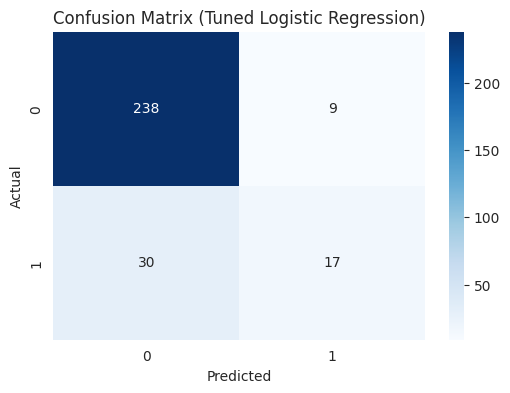

In [10]:
# ## 10) Confusion Matrix (Tuned Model)

# %%
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Tuned Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11) ROC Curve (Tuned Model)

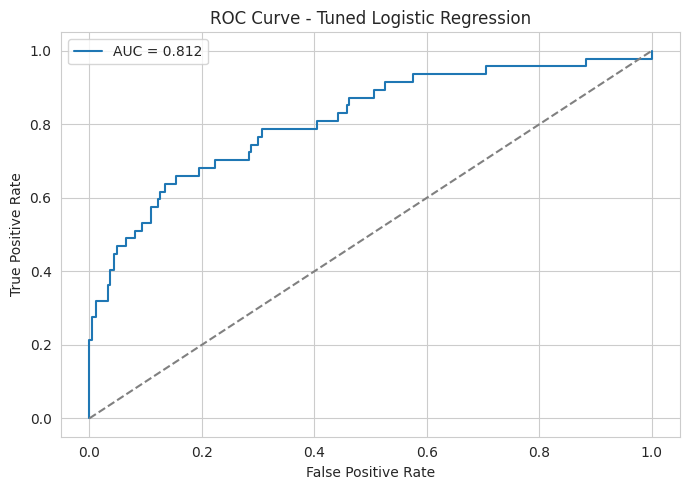

In [11]:
# ## 11) ROC Curve (Tuned Model)

# %%
fpr, tpr, _ = roc_curve(y_test, y_proba_best)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {best_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Logistic Regression")
plt.legend()
plt.tight_layout()
plt.show()

# 12) Threshold Tuning (F1-based with Recall Constraint)

In [20]:
from sklearn.metrics import accuracy_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-12)

target_recall = 0.60
valid = recalls[:-1] >= target_recall

if valid.any():
    best_idx = np.argmax(f1s[valid])
    best_thresh = thresholds[valid][best_idx]
    note = "✅ Found threshold meeting recall constraint."
else:
    best_thresh = 0.5
    note = "⚠️ No threshold met recall constraint; using 0.5."

y_pred_thr = (y_proba_best >= best_thresh).astype(int)

print(note)
print(f"Best threshold: {best_thresh:.4f} (Recall constraint >= {target_recall})")
print("Accuracy :", accuracy_score(y_test, y_pred_thr))
print("Precision:", precision_score(y_test, y_pred_thr))
print("Recall   :", recall_score(y_test, y_pred_thr))
print("F1       :", f1_score(y_test, y_pred_thr))

✅ Found threshold meeting recall constraint.
Best threshold: 0.2323 (Recall constraint >= 0.6)
Accuracy : 0.8299319727891157
Precision: 0.47619047619047616
Recall   : 0.6382978723404256
F1       : 0.5454545454545454


# 13) Cross-Validation Scores (10-fold ROC-AUC)

In [13]:
# ## 13) Cross-Validation Scores (10-fold ROC-AUC)

# %%
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_train, y_train, scoring="roc_auc", cv=cv10, n_jobs=-1)

print("10-fold ROC-AUC:", np.round(cv_scores, 4))
print(f"Mean ± Std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


10-fold ROC-AUC: [0.8341 0.8198 0.8825 0.7682 0.9293 0.8033 0.8437 0.9372 0.8985 0.7186]
Mean ± Std: 0.8435 ± 0.0665


# 14) Baseline vs Balanced vs Tuned Comparison

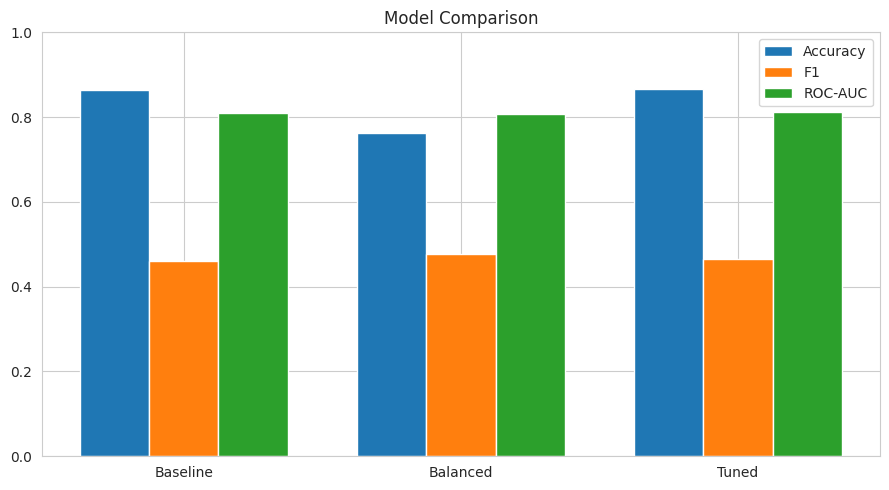

In [14]:
# ## 14) Baseline vs Balanced vs Tuned Comparison

# %%
models = ["Baseline", "Balanced", "Tuned"]
accs = [base_acc, bal_acc, best_acc]
f1s_ = [base_f1, bal_f1, best_f1]
aucs = [base_auc, bal_auc, best_auc]

x = np.arange(len(models))
w = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - w, accs, width=w, label="Accuracy")
plt.bar(x, f1s_, width=w, label="F1")
plt.bar(x + w, aucs, width=w, label="ROC-AUC")
plt.xticks(x, models)
plt.ylim(0, 1)
plt.title("Model Comparison")
plt.legend()
plt.tight_layout()
plt.show()


# 15) Final Summary

In [27]:
# ## 15) Final Summary

# %%
# number of final transformed features
n_features = best_model.named_steps["preprocess"].get_feature_names_out().shape[0]

summary = pd.DataFrame({
    "Model": ["Baseline", "Balanced", "Tuned"],
    "Accuracy": [base_acc, bal_acc, best_acc],
    "F1": [base_f1, bal_f1, best_f1],
    "ROC-AUC": [base_auc, bal_auc, best_auc],
})

print("═" * 70)
print("FINAL RESULTS SUMMARY – LOGISTIC REGRESSION")
print("═" * 70)
print("Dataset: IBM HR Analytics Employee Attrition")
print("Target : Attrition (1 = Yes, 0 = No)")
print(f"Train samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")
print(f"Final feature count (after OHE + scaling + engineering): {n_features}")
print("Best tuned params:", grid.best_params_)
print(f"Best threshold (recall>=0.60, max F1): {best_thresh:.4f}")
print(f"CV ROC-AUC (10-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("═" * 70)

display(summary.sort_values("ROC-AUC", ascending=False))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Probabilities from best (tuned) model
y_proba = y_proba_best  # from best_pipeline/best_model

# Use your tuned threshold (best_thresh)
final_thresh = best_thresh
y_pred_final = (y_proba >= final_thresh).astype(int)

final_accuracy  = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall    = recall_score(y_test, y_pred_final)      # sensitivity for class 1
final_f1        = f1_score(y_test, y_pred_final)
final_auc       = roc_auc_score(y_test, y_proba)          # uses probabilities (not threshold)

print("=== FINAL BEST METRICS (Tuned Model + Tuned Threshold) ===")
print(f"Threshold used       : {final_thresh:.4f}")
print(f"Accuracy             : {final_accuracy:.4f}")
print(f"Precision            : {final_precision:.4f}")
print(f"Recall (Sensitivity) : {final_recall:.4f}")
print(f"F1-score             : {final_f1:.4f}")
print(f"ROC-AUC              : {final_auc:.4f}")

══════════════════════════════════════════════════════════════════════
FINAL RESULTS SUMMARY – LOGISTIC REGRESSION
══════════════════════════════════════════════════════════════════════
Dataset: IBM HR Analytics Employee Attrition
Target : Attrition (1 = Yes, 0 = No)
Train samples: 1176 | Test samples: 294
Final feature count (after OHE + scaling + engineering): 53
Best tuned params: {'clf__C': 1, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Best threshold (recall>=0.60, max F1): 0.2323
CV ROC-AUC (10-fold): 0.8435 ± 0.0665
══════════════════════════════════════════════════════════════════════


,Model,Accuracy,F1,ROC-AUC
2,Tuned,0.867347,0.465753,0.811526
0,Baseline,0.863946,0.459459,0.810750
1,Balanced,0.761905,0.477612,0.807994


=== FINAL BEST METRICS (Tuned Model + Tuned Threshold) ===
Threshold used       : 0.2323
Accuracy             : 0.8299
Precision            : 0.4762
Recall (Sensitivity) : 0.6383
F1-score             : 0.5455
ROC-AUC              : 0.8115
